1> Dataset Generation

In [1]:
# Synthetic dataset means it is an artificial dataset that looks realistic and useful for machine learning pratices and no privacy isuues

# Loading the libraries that are required
import pandas as pd
import numpy as np
import random

np.random.seed(42) # seed() helps to keep the generated random values same every time we execute

n=2000 # n is the total number of records of data

# Initializing some categorical values
education_levels = ["Bachelor's", "Master's", "PhD"]
job_roles = ["Developer", "Data Analyst", "Manager", "Designer", "Tester"]
company_types = ["Startup", "MNC", "Medium Scale"]
genders = ["Male", "Female"]

# The rows which are going to be generated will be stored in the below list
data=[]

for i in range(n):
    age = np.random.randint(21, 60) # selects the age randomly between 21 to 60
    gender=np.random.choice(genders) # selects male or female
    experience = np.random.randint(0, 20) # selects experience randomly between 0 to 20 years
    education = random.choice(education_levels) # selects education from the above initialized educational levels
    job_role = random.choice(job_roles) # selects job role from the above initialized job roles
    company = random.choice(company_types) # selets company types
    skills_score = np.random.randint(1, 11) # gives skills score based thier technical and non technical skills
    certifications = np.random.randint(0, 11) # gives random number of certifications that are done
    work_hours = np.random.randint(30, 60) # selects work hours per week between 30 to 60
    
    base_salary=300000 #initializing base salary to 300000 

    # formula for generating salary
    # salary is based on experience,skills score,certifications
    salary = (
    base_salary
    + (experience * 50000) #experience * 50000 rupees 
    + (skills_score * 15000)#skills_score * 15000 rupees
    + (certifications * 10000)#number of certifications * 10000 rupees
    )

    #eduction impact
    if education == "Master's":
        salary += 100000
    elif education == "PhD":
        salary += 200000

    #job role impact
    if job_role == "Manager":
        salary += 250000
    elif job_role == "Developer":
        salary += 150000
    elif job_role == "Data Analyst":
        salary += 120000
    elif job_role == "Designer":
        salary += 80000
    elif job_role == "Tester":
        salary += 70000

    #company type impact
    if company == "MNC":
        salary += 200000
    elif company == "Startup":
        salary += 50000
    elif company == "Medium Scale":
        salary += 100000
    
    # Work Hours Bonus
    salary += work_hours * 1000

    #adding some noise because in real life two people having same experience can have different salaries and to make the data more realistic
    salary += np.random.randint(-50000, 50000) 

    #each employee row is added to the data
    data.append([
    i + 1,
    age,
    gender,
    education,
    experience,
    job_role,
    skills_score,
    certifications,
    company,
    work_hours,
    salary
    ])

# these are the columns that are mentioned to create 
columns = [
    "EmployeeID",
    "Age",
    "Gender",
    "EducationLevel",
    "YearsOfExperience",
    "JobRole",
    "SkillsScore",
    "Certifications",
    "CompanyType",
    "WorkHoursPerWeek",
    "Salary"
]

# this step helps to convert the data into a dataframe i.e., in table format
df = pd.DataFrame(data, columns=columns)

# converts the generated dataframe into a csv file which helps to do further steps
df.to_csv("employee_salary_dataset.csv", index=False)

print("Dataset Generated Successfully!")
print(df.head()) # prints the starting 5 rows

Dataset Generated Successfully!
   EmployeeID  Age  Gender EducationLevel  YearsOfExperience       JobRole  \
0           1   59  Female     Bachelor's                 14     Developer   
1           2   39    Male     Bachelor's                 10        Tester   
2           3   44    Male     Bachelor's                  1       Manager   
3           4   41    Male            PhD                 11  Data Analyst   
4           5   47    Male     Bachelor's                  9       Manager   

   SkillsScore  Certifications   CompanyType  WorkHoursPerWeek   Salary  
0            8               4  Medium Scale                36  1402265  
1            8               4  Medium Scale                33  1173263  
2            8               5       Startup                31   806311  
3           10               5       Startup                58  1521016  
4            3               6       Startup                49  1185551  


2> Data Preprocessing

In [2]:
# Preprocessing data
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"D:\Employee_Salary_Prediction\employee_salary_dataset.csv") #reading csv file which is generated before
print(df.head())

   EmployeeID  Age  Gender EducationLevel  YearsOfExperience       JobRole  \
0           1   59  Female     Bachelor's                 14  Data Analyst   
1           2   39    Male            PhD                 10  Data Analyst   
2           3   44    Male     Bachelor's                  1        Tester   
3           4   41    Male     Bachelor's                 11        Tester   
4           5   47    Male     Bachelor's                  9       Manager   

   SkillsScore  Certifications CompanyType  WorkHoursPerWeek   Salary  
0            8               4     Startup                36  1322265  
1            8               4     Startup                33  1373263  
2            8               5     Startup                31   626311  
3           10               5     Startup                58  1271016  
4            3               6         MNC                49  1335551  


In [4]:
print("Dataset Shape:",df.shape) # shape() prints the shape of dataset

Dataset Shape: (2000, 11)


In [5]:
# Handling missing values

print("---------- MISSING VALUES ----------")
print(df.isnull().sum())

---------- MISSING VALUES ----------
EmployeeID           0
Age                  0
Gender               0
EducationLevel       0
YearsOfExperience    0
JobRole              0
SkillsScore          0
Certifications       0
CompanyType          0
WorkHoursPerWeek     0
Salary               0
dtype: int64


In [6]:
# Filling missing numerical values with median if any

numerical_columns=[
    "Age",
    "YearsOfExperience",
    "SkillsScore",
    "Certifications",
    "WorkHoursPerWeek",
    "Salary"
]
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Filling missing categorical values with mode if any

categorical_columns=[
    "Gender",
    "EducationLevel",
    "JobRole",
    "CompanyType"
]
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hansi\AppData\Local\Temp\ipykernel_22112\3590636286.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\hansi\AppData\Local\Temp\ipykernel_22112\3590636286.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [7]:
# Removing Duplicate Rows

duplicate_count=df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_count)
df.drop_duplicates(inplace=True)
if duplicate_count>0 :
    print("Duplicates removed successfully!")


Duplicate Rows: 0


In [8]:
# Step 6: Data Validation

print("---------- DATA VALIDATION ----------")

# Check negative salaries
negative_salary=(df["Salary"]<0).sum()
print("\nNegative Salary Records:",negative_salary)

# Check invalid ages
invalid_age=((df["Age"]<18)).sum()
print("\nInvalid Age Records:", invalid_age)

# Check invalid work hours
invalid_workhours = ((df["WorkHoursPerWeek"] <= 0)).sum()
print("\nInvalid WorkHoursPerWeek Records:",invalid_workhours)

# Check final dataset info
print("\n---------- FINAL DATASET INFO ----------\n")
print(df.info())

print("\n---------- CLEANED DATASET ----------\n")
print(df.head())

---------- DATA VALIDATION ----------

Negative Salary Records: 0

Invalid Age Records: 0

Invalid WorkHoursPerWeek Records: 0

---------- FINAL DATASET INFO ----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         2000 non-null   int64 
 1   Age                2000 non-null   int64 
 2   Gender             2000 non-null   object
 3   EducationLevel     2000 non-null   object
 4   YearsOfExperience  2000 non-null   int64 
 5   JobRole            2000 non-null   object
 6   SkillsScore        2000 non-null   int64 
 7   Certifications     2000 non-null   int64 
 8   CompanyType        2000 non-null   object
 9   WorkHoursPerWeek   2000 non-null   int64 
 10  Salary             2000 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 172.0+ KB
None

---------- CLEANED DATASET ----------

   EmployeeID  

In [9]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
print("---------- FEATURE SCALING ----------")
scaler=StandardScaler()
scaling_columns=[
    "Age",
    "YearsOfExperience",
    "SkillsScore",
    "Certifications",
    "WorkHoursPerWeek"
]
df[scaling_columns]=scaler.fit_transform(df[scaling_columns])
print("Feature scaling completed!")

---------- FEATURE SCALING ----------
Feature scaling completed!


In [10]:
df.head()

,EmployeeID,Age,Gender,EducationLevel,YearsOfExperience,JobRole,SkillsScore,Certifications,CompanyType,WorkHoursPerWeek,Salary
0,1,1.693837,Female,Bachelor's,0.783078,Data Analyst,0.876972,-0.303132,Startup,-1.046555,1322265
1,2,-0.109604,Male,PhD,0.084603,Data Analyst,0.876972,-0.303132,Startup,-1.394017,1373263
2,3,0.341256,Male,Bachelor's,-1.486967,Tester,0.876972,0.016628,Startup,-1.625658,626311
3,4,0.070740,Male,Bachelor's,0.259222,Tester,1.563850,0.016628,Startup,1.501498,1271016
4,5,0.611772,Male,Bachelor's,-0.090016,Manager,-0.840224,0.336387,MNC,0.459113,1335551


In [11]:
# Saving preprocessed data

output_path = r"D:\Employee_Salary_Prediction\preprocessed_employee_salary_dataset.csv"

df.to_csv(output_path, index=False)

print("Preprocessed dataset saved successfully!")
print("Location:", output_path)

Preprocessed dataset saved successfully!
Location: D:\Employee_Salary_Prediction\preprocessed_employee_salary_dataset.csv


3> Exploratory Data Analysis(EDA)

In [12]:
# Exploratory Data Analysis (EDA)

# Basic Dataset Information

print("---------- FIRST 5 RECORDS ----------")
print(df.head())

print("\n---------- DATASET SHAPE ----------")
print(df.shape)

print("\n---------- COLUMN NAMES ----------")
print(df.columns)

print("\n---------- DATA TYPES ----------")
print(df.dtypes)

# STATISTICAL SUMMARY 
print("\n Describe() :")
print(df.describe())

# Missing Values Analysis
print("\n---------- MISSING VALUES ----------")
print(df.isnull().sum())

# Duplicate Records Analysis
print("\n---------- DUPLICATE RECORDS ----------")
print(df.duplicated().sum())

---------- FIRST 5 RECORDS ----------
   EmployeeID       Age  Gender EducationLevel  YearsOfExperience  \
0           1  1.693837  Female     Bachelor's           0.783078   
1           2 -0.109604    Male            PhD           0.084603   
2           3  0.341256    Male     Bachelor's          -1.486967   
3           4  0.070740    Male     Bachelor's           0.259222   
4           5  0.611772    Male     Bachelor's          -0.090016   

        JobRole  SkillsScore  Certifications CompanyType  WorkHoursPerWeek  \
0  Data Analyst     0.876972       -0.303132     Startup         -1.046555   
1  Data Analyst     0.876972       -0.303132     Startup         -1.394017   
2        Tester     0.876972        0.016628     Startup         -1.625658   
3        Tester     1.563850        0.016628     Startup          1.501498   
4       Manager    -0.840224        0.336387         MNC          0.459113   

    Salary  
0  1322265  
1  1373263  
2   626311  
3  1271016  
4  1335551  


In [13]:
# Relationship Between Experience and Salary

print("---------- EXPERIENCE VS SALARY ----------")
experience_salary=df[["YearsOfExperience", "Salary"]].corr()
print(experience_salary)
average_salary_experience=df.groupby("YearsOfExperience")["Salary"].mean()
print("\nAverage Salary Based on Experience:\n")
print(average_salary_experience)

---------- EXPERIENCE VS SALARY ----------
                   YearsOfExperience    Salary
YearsOfExperience           1.000000  0.903038
Salary                      0.903038  1.000000

Average Salary Based on Experience:

YearsOfExperience
-1.661586    8.286734e+05
-1.486967    8.501426e+05
-1.312348    9.059922e+05
-1.137729    9.754102e+05
-0.963110    1.044644e+06
-0.788491    1.089103e+06
-0.613873    1.128625e+06
-0.439254    1.205934e+06
-0.264635    1.216557e+06
-0.090016    1.256370e+06
 0.084603    1.326682e+06
 0.259222    1.385997e+06
 0.433841    1.421218e+06
 0.608459    1.473493e+06
 0.783078    1.527513e+06
 0.957697    1.592601e+06
 1.132316    1.629655e+06
 1.306935    1.695486e+06
 1.481554    1.738347e+06
 1.656173    1.776949e+06
Name: Salary, dtype: float64


In [14]:
# Impact of Education Level on Salary

print("---------- EDUCATION LEVEL VS SALARY ----------")
education_salary=df.groupby("EducationLevel")["Salary"].agg(["mean", "min", "max"])
print(education_salary)

---------- EDUCATION LEVEL VS SALARY ----------
                        mean     min      max
EducationLevel                               
Bachelor's      1.182978e+06  478731  1871350
Master's        1.313189e+06  653265  1985386
PhD             1.420206e+06  730424  2151707


In [15]:
# Salary Distribution Across Job Roles

print("---------- JOB ROLE VS SALARY ----------")
jobrole_salary=df.groupby("JobRole")["Salary"].agg(["mean", "min", "max"])
print(jobrole_salary)

---------- JOB ROLE VS SALARY ----------
                      mean     min      max
JobRole                                    
Data Analyst  1.310968e+06  616418  2069613
Designer      1.230419e+06  564055  1950925
Developer     1.288868e+06  591745  2063856
Manager       1.446968e+06  761985  2151707
Tester        1.243034e+06  478731  1895405


In [16]:
#Correlation Matrix

print("---------- CORRELATION MATRIX ----------")
correlation_matrix=df.corr(numeric_only=True)
print(correlation_matrix)

---------- CORRELATION MATRIX ----------
                   EmployeeID       Age  YearsOfExperience  SkillsScore  \
EmployeeID           1.000000 -0.026205           0.037459    -0.009099   
Age                 -0.026205  1.000000           0.006147    -0.005798   
YearsOfExperience    0.037459  0.006147           1.000000    -0.027717   
SkillsScore         -0.009099 -0.005798          -0.027717     1.000000   
Certifications      -0.004151 -0.003440          -0.020614     0.023086   
WorkHoursPerWeek    -0.006291  0.014765          -0.000982     0.006481   
Salary               0.038444  0.006443           0.903038     0.121227   

                   Certifications  WorkHoursPerWeek    Salary  
EmployeeID              -0.004151         -0.006291  0.038444  
Age                     -0.003440          0.014765  0.006443  
YearsOfExperience       -0.020614         -0.000982  0.903038  
SkillsScore              0.023086          0.006481  0.121227  
Certifications           1.000000     

In [17]:
# Top Correlations with Salary

print("---------- FEATURES MOST RELATED TO SALARY ----------")
salary_correlation=correlation_matrix["Salary"].sort_values(ascending=False)
print(salary_correlation)

---------- FEATURES MOST RELATED TO SALARY ----------
Salary               1.000000
YearsOfExperience    0.903038
SkillsScore          0.121227
Certifications       0.074000
EmployeeID           0.038444
WorkHoursPerWeek     0.030786
Age                  0.006443
Name: Salary, dtype: float64


In [18]:
# Skills Score Impact on Salary

print("---------- SKILLS SCORE VS SALARY ----------")
skills_salary=df.groupby("SkillsScore")["Salary"].mean()
print(skills_salary)

---------- SKILLS SCORE VS SALARY ----------
SkillsScore
-1.527102    1.250903e+06
-1.183663    1.273382e+06
-0.840224    1.266192e+06
-0.496785    1.253193e+06
-0.153346    1.311305e+06
 0.190094    1.291890e+06
 0.533533    1.320430e+06
 0.876972    1.375293e+06
 1.220411    1.342562e+06
 1.563850    1.363863e+06
Name: Salary, dtype: float64


In [19]:
# Certifications Impact on Salary

print("---------- CERTIFICATIONS VS SALARY ----------")
certification_salary=df.groupby("Certifications")["Salary"].mean()
print(certification_salary)

---------- CERTIFICATIONS VS SALARY ----------
Certifications
-1.582172    1.285651e+06
-1.262412    1.251507e+06
-0.942652    1.280223e+06
-0.622892    1.285266e+06
-0.303132    1.274480e+06
 0.016628    1.340564e+06
 0.336387    1.303656e+06
 0.656147    1.351142e+06
 0.975907    1.311683e+06
 1.295667    1.326800e+06
 1.615427    1.343029e+06
Name: Salary, dtype: float64


In [20]:
# Company Type Impact on Salary

print("\n---------- COMPANY TYPE VS SALARY ----------")

company_salary=df.groupby("CompanyType")["Salary"].agg(["mean", "min", "max"])
print(company_salary)


---------- COMPANY TYPE VS SALARY ----------
                      mean     min      max
CompanyType                                
MNC           1.382450e+06  665415  2151707
Medium Scale  1.285145e+06  564055  1991044
Startup       1.234945e+06  478731  1942475


4> Data Visualization

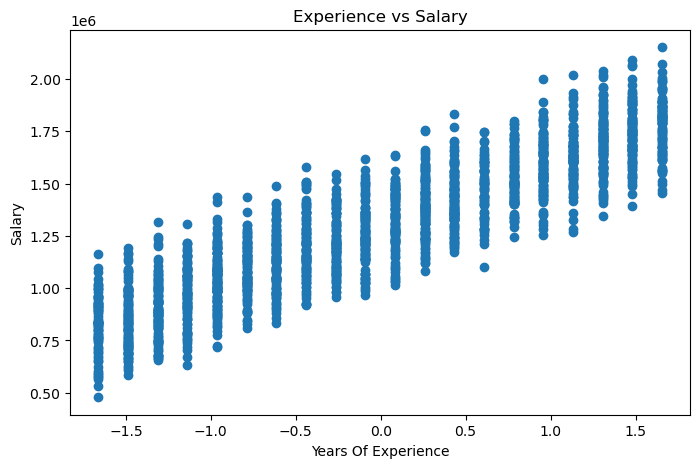

In [21]:
import matplotlib.pyplot as plt
# Experience vs Salary

plt.figure(figsize=(8,5))
plt.scatter(
    df["YearsOfExperience"],
    df["Salary"]
)
plt.title("Experience vs Salary")
plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.show()

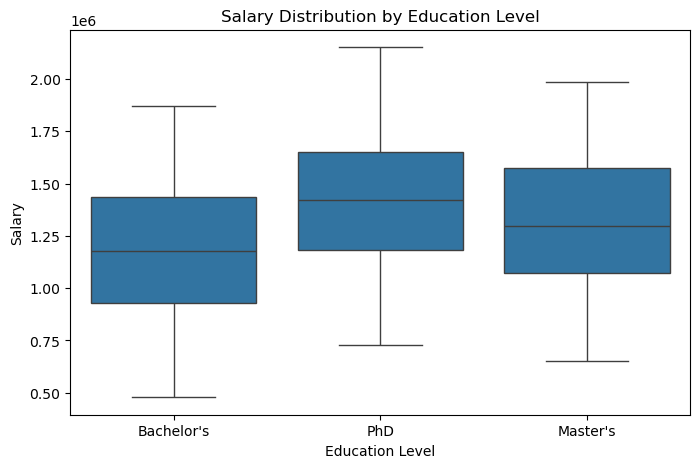

In [22]:
# Salary Distribution by Education Level

plt.figure(figsize=(8,5))
sns.boxplot(
    x="EducationLevel",
    y="Salary",
    data=df
)
plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Salary")
plt.show()

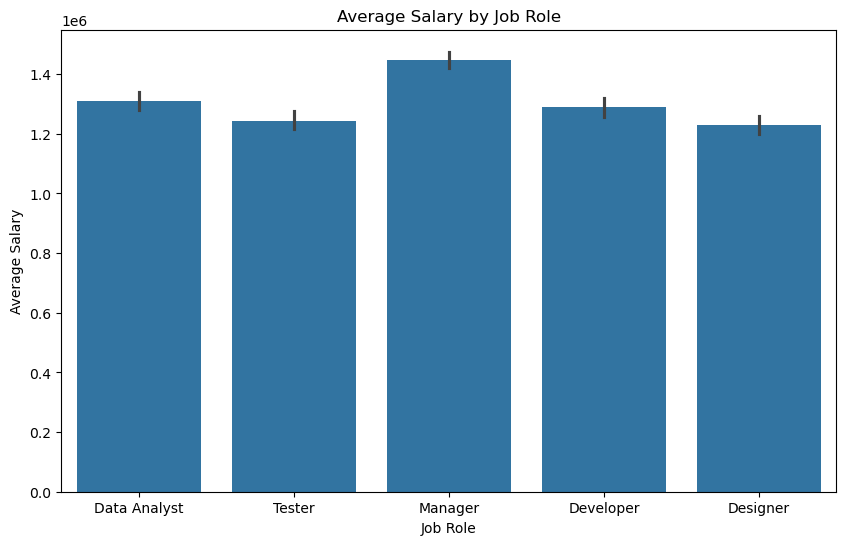

In [23]:
# Average Salary by Job Role

plt.figure(figsize=(10,6))
sns.barplot(
    x="JobRole",
    y="Salary",
    data=df
)
plt.title("Average Salary by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")
plt.show()

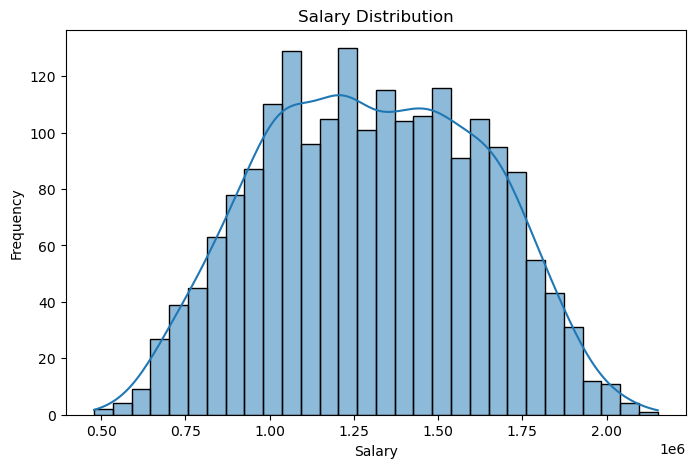

In [24]:
# Salary Distribution Histogram

plt.figure(figsize=(8,5))
sns.histplot(
    df["Salary"],
    bins=30,
    kde=True
)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

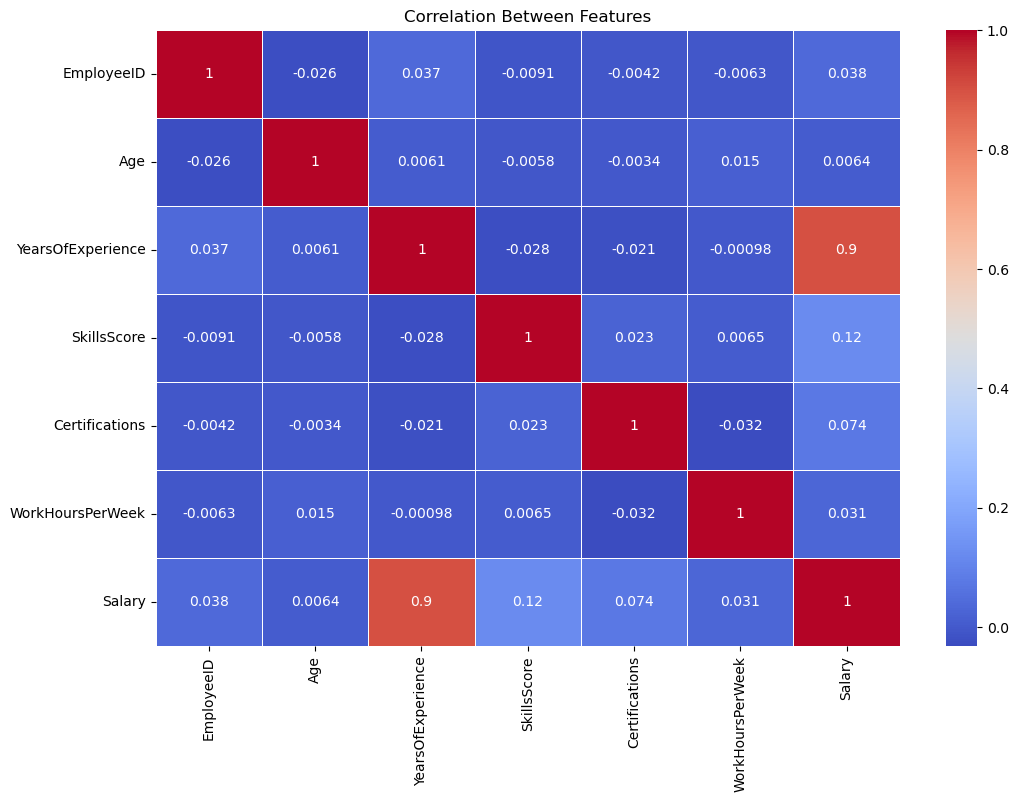

In [25]:
# correlation between features

plt.figure(figsize=(12,8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Between Features")
plt.show()

5> Machine Learning Model

In [26]:
# Machine Learning Regression Model

# Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [27]:
# Encode Categorical Columns

label_encoders={}
categorical_columns=[
    "Gender",
    "EducationLevel",
    "JobRole",
    "CompanyType"
]
for col in categorical_columns:
    encoder=LabelEncoder()
    df[col]=encoder.fit_transform(df[col])
    label_encoders[col]=encoder

In [28]:
# Features and Target Variable

X=df.drop(["EmployeeID","Salary"],axis=1)
y=df["Salary"]

In [29]:
# Split Dataset into Training and Testing

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

Training Data Shape: (1600, 9)
Testing Data Shape: (400, 9)


In [30]:
# Create Models

linear_model=LinearRegression()
decision_tree_model=DecisionTreeRegressor(random_state=42)
random_forest_model = RandomForestRegressor(n_estimators=100,random_state=42)

In [31]:
# Train Models

linear_model.fit(X_train,y_train)
decision_tree_model.fit(X_train,y_train)
random_forest_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Predictions

linear_pred=linear_model.predict(X_test)
decision_tree_pred=decision_tree_model.predict(X_test)
random_forest_pred=random_forest_model.predict(X_test)

In [33]:
# Evaluation Function

def evaluate_model(model_name,y_test,predictions):
    mae=mean_absolute_error(y_test,predictions)
    rmse = np.sqrt(mean_squared_error(y_test,predictions))
    r2 = r2_score(y_test,predictions)
    print(f"\n========== {model_name} ==========")
    print("MAE :",mae)
    print("RMSE:",rmse)
    print("R2 Score:",r2)

# Evaluate Models

evaluate_model("Linear Regression",y_test,linear_pred)
evaluate_model("Decision Tree Regressor",y_test,decision_tree_pred)
evaluate_model("Random Forest Regressor",y_test,random_forest_pred)


========== Linear Regression ==========
MAE : 57209.66324747587
RMSE: 71249.34381294808
R2 Score: 0.9518296070226068

========== Decision Tree Regressor ==========
MAE : 87144.235
RMSE: 110644.59586766992
R2 Score: 0.883834045532631

========== Random Forest Regressor ==========
MAE : 53720.719500000014
RMSE: 67102.46037423675
R2 Score: 0.9572736946467517


In [35]:
model = random_forest_model  # choose best performing model

6> Console-Based Prediction System

In [37]:
# =========================================
# Employee Salary Prediction System
# Console-Based Prediction System
# With Proper Error Handling
# =========================================

#valid inputs

valid_genders = ["Male", "Female"]

valid_education = [
    "Bachelor's",
    "Master's",
    "PhD"
]

valid_job_roles = [
    "Developer",
    "Data Analyst",
    "Manager",
    "Designer",
    "Tester"
]

valid_company_types = [
    "Startup",
    "MNC",
    "Medium Scale"
]

# =========================================
# Console Interface
# =========================================

print("\n------------------------------------")
print(" EMPLOYEE SALARY PREDICTION SYSTEM ")
print("-------------------------------------\n")

try:

    # =========================================
    # Age Validation
    # =========================================

    # =========================================
    # Gender Validation
    # =========================================

    age = int(input("Enter Age: ").strip())
    

    gender = input("Enter Gender (Male/Female): ").strip()
    print("DEBUG Gender:", gender)

    if gender not in valid_genders:
        raise ValueError("Invalid Gender Entered.")

    if age < 18 or age > 65:
        raise ValueError("Age must be between 18 and 65.")


    # =========================================
    # Education Validation
    # =========================================

    education = input("Enter Education Level (Bachelor's/Master's/PhD): ").strip()

    if education not in valid_education:
        raise ValueError("Invalid Education Level Entered.")

    # =========================================
    # Experience Validation
    # =========================================

    experience = int(input("Enter Years of Experience: "))

    if experience < 0 or experience > 40:
        raise ValueError("Experience must be between 0 and 40.")

    # =========================================
    # Skills Score Validation
    # =========================================

    skills_score = int(input("Enter Skills Score (1-10): "))

    if skills_score < 1 or skills_score > 10:
        raise ValueError("Skills Score must be between 1 and 10.")

    # =========================================
    # Certifications Validation
    # =========================================

    certifications = int(input("Enter Number of Certifications: "))

    if certifications < 0:
        raise ValueError("Certifications cannot be negative.")

    # =========================================
    # Job Role Validation
    # =========================================

    job_role = input("Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester): ").strip()

    if job_role not in valid_job_roles:
        raise ValueError("Invalid Job Role Entered.")

    # =========================================
    # Company Type Validation
    # =========================================

    company_type = input("Enter Company Type (Startup/MNC/Medium Scale): ").strip()

    if company_type not in valid_company_types:
        raise ValueError("Invalid Company Type Entered.")

    # =========================================
    # Work Hours Validation
    # =========================================

    work_hours = int(input("Enter Work Hours Per Week: "))

    if work_hours < 20 or work_hours > 100:
        raise ValueError("Work hours must be between 20 and 100.")

    # =========================================
    # Encode User Inputs
    # =========================================

    gender_encoded = label_encoders["Gender"].transform([gender])[0]
    education_encoded = label_encoders["EducationLevel"].transform([education])[0]
    job_role_encoded = label_encoders["JobRole"].transform([job_role])[0]
    company_encoded = label_encoders["CompanyType"].transform([company_type])[0]

    # =========================================
    # Create Input DataFrame
    # =========================================

    input_df = pd.DataFrame([{
        "Age": age,
        "Gender": gender_encoded,
        "EducationLevel": education_encoded,
        "YearsOfExperience": experience,
        "JobRole": job_role_encoded,
        "SkillsScore": skills_score,
        "Certifications": certifications,
        "CompanyType": company_encoded,
        "WorkHoursPerWeek": work_hours
    }])

    # =========================================
    # Predict Salary
    # =========================================

    predicted_salary = model.predict(input_df)

    # =========================================
    # Display Result
    # =========================================

    print("\n------------------------------------")
    print(" PREDICTED EMPLOYEE SALARY ")
    print("------------------------------------\n")

    print(f"Estimated Annual Salary: ₹{predicted_salary[0]:,.2f}")

# =========================================
# Error Handling
# =========================================

except ValueError as ve:

    print("\nINPUT ERROR:", ve)

except Exception as e:

    print("\nSYSTEM ERROR:", e)

finally:

    print("\nProgram Executed Successfully.")


------------------------------------
 EMPLOYEE SALARY PREDICTION SYSTEM 
-------------------------------------



Enter Age:  24
Enter Gender (Male/Female):  Male


DEBUG Gender: Male


Enter Education Level (Bachelor's/Master's/PhD):  PhD
Enter Years of Experience:  3
Enter Skills Score (1-10):  9
Enter Number of Certifications:  3
Enter Job Role (Developer/Data Analyst/Manager/Designer/Tester):  Tester
Enter Company Type (Startup/MNC/Medium Scale):  MNC
Enter Work Hours Per Week:  40



------------------------------------
 PREDICTED EMPLOYEE SALARY 
------------------------------------

Estimated Annual Salary: ₹1,951,902.77

Program Executed Successfully.
